<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula01c_perceptron%20with%20bias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

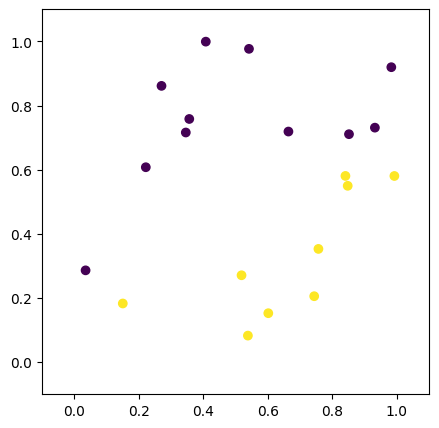

In [58]:
import numpy as np
import matplotlib.pyplot as plt

def createDataset(n=20, coef=0.5, intercept=0.2):
  X = np.random.rand(n,2)
  y = np.array(X[:,0]*coef>(X[:,1]-intercept), dtype=int)*2-1
  return X, y

X, y = createDataset()

def plotDataset(X, y):
  plt.figure(figsize=(5,5))
  plt.scatter(X[:,0], X[:,1], c=y)
  plt.xlim(-0.1,1.1)
  plt.ylim(-0.1,1.1)

plotDataset(X, y)
plt.show()

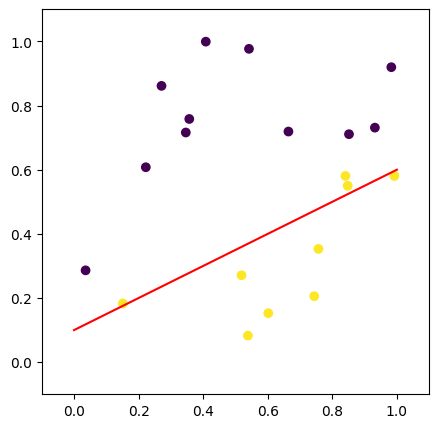

In [73]:
def plotHyperplan(vector, intercept=0):
  xs = np.array([0,1])
  ys = -(vector[0]*(xs+intercept))/vector[1]
  plt.plot(xs, ys, 'r-')

plotDataset(X, y)
plotHyperplan(np.array([1,-2]), 0.2)
plt.show()

Accuracy: 1.0
Weights: [ 23.22165232 -43.94775168], 8.902259724043802


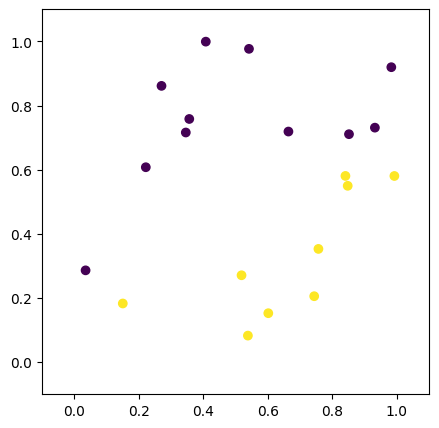

In [74]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

def sign(a):
  return (a>=0)*2-1

class Perceptron(BaseEstimator, ClassifierMixin):
  def __init__(self, max_iter=100):
    self.max_iter = max_iter

  def fit(self, X, y):
    self.w_ = np.random.uniform(size=(X.shape[1],))*2-1
    self.b_ = np.random.uniform()
    # Notação vetorial
    for _ in range(self.max_iter):
      cost = 0
      ypred = self.predict(X)
      error = y - ypred
      self.w_ = self.w_ + X.T @ error
      self.b_ = self.b_ + np.sum(error)
      cost = np.sum(error**2)
      if cost == 0:
        break
    return self

  def predict(self, X):
    logits = X @ self.w_ + self.b_
    ypred = sign(logits)
    return ypred

clf = Perceptron()
clf.fit(X, y)
ypred = clf.predict(X)
print(f"Accuracy: {accuracy_score(y, ypred)}")
print(f"Weights: {clf.w_}, {clf.b_}")
plotDataset(X, y)
plotHyperplan(clf.w_, clf.b_)
plt.show()

Accuracy: 0.983


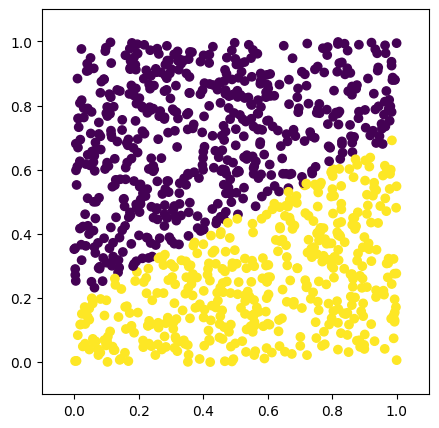

In [76]:
X_test, y_test = createDataset(1000)
ypred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, ypred))
plotDataset(X_test, y_test)
plotHyperplan(clf.w_, clf.b_)
plt.show()

Accuracy: 1.0
Weights: [-17.01214927 -54.127976  ], 34.02065773701693


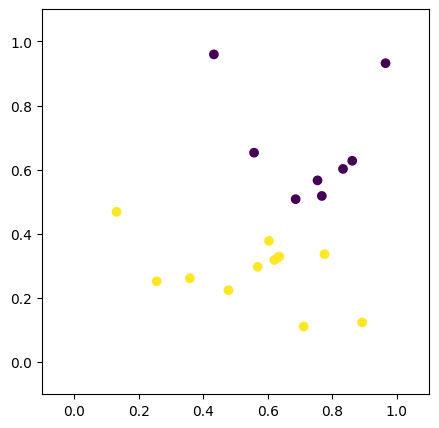

In [84]:
X, y = createDataset(20, -0.5, 0.8)
clf = Perceptron()
clf.fit(X, y)
ypred = clf.predict(X)
print(f"Accuracy: {accuracy_score(y, ypred)}")
print(f"Weights: {clf.w_}, {clf.b_}")
plotDataset(X, y)
plotHyperplan(clf.w_, clf.b_)
plt.show()

Accuracy: 0.937


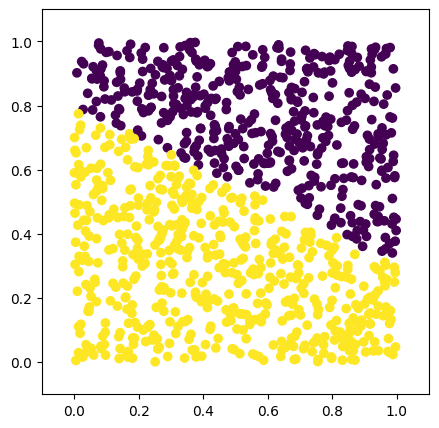

In [86]:
X_test, y_test = createDataset(1000, -0.5, 0.8)
ypred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, ypred))
plotDataset(X_test, y_test)
plotHyperplan(clf.w_, clf.b_)
plt.show()